In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')

### The data download from [our world in data](https://ourworldindata.org/grapher/gdp-per-capita-worldbank)

In [88]:
df = pd.read_csv("gdp-per-capita-worldbank.csv")

# filter out 3 counties
countries = ["China", "India", "Japan"]
df = df[df.Entity.isin(countries)]
df.rename(columns={"GDP per capita, PPP (constant 2017 international $)": "GDP per capita"}, inplace=True)
df.head()

,Entity,Code,Year,GDP per capita
1255,China,CHN,1990,1423.896348
1256,China,CHN,1991,1534.705272
1257,China,CHN,1992,1731.657215
1258,China,CHN,1993,1949.534268
1259,China,CHN,1994,2178.924057


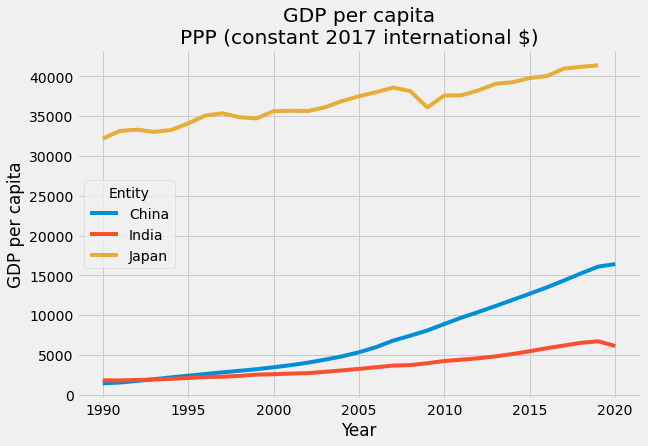

In [89]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.lineplot(data=df, x="Year", y="GDP per capita", hue="Entity", ax=ax)
ax.set_title("GDP per capita\nPPP (constant 2017 international $)")
plt.show()

In [90]:
pivot = df.pivot_table(
    values="GDP per capita",
    index ="Year",
    columns="Entity",
)
pivot.head()

Entity,China,India,Japan
Year,,,
1990,1423.896348,1813.135853,32168.764114
1991,1534.705272,1795.302326,33137.703111
1992,1731.657215,1856.170582,33294.916038
1993,1949.534268,1906.412058,33015.276573
1994,2178.924057,1994.226916,33250.178510


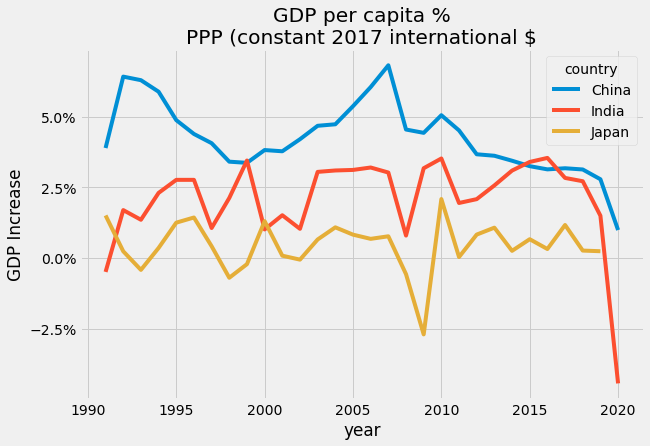

In [92]:
import matplotlib.ticker as mtick
df = pd.DataFrame(
    data=pivot.values[1:] / pivot.values[:-1] - 1,
    columns = countries, index = pivot.index[1:]
).unstack().reset_index()
df.columns = ['country', 'year', 'GDP Increase']
fig, ax = plt.subplots(figsize=(9, 6))
sns.lineplot(data=df, x="year", y="GDP Increase", hue="country", ax=ax)
ax.set_title("GDP per capita %\nPPP (constant 2017 international $")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(2))
plt.show()